In [1]:
# ============================================================
# CELL 1 — INSTALL REQUIRED PACKAGES
# ============================================================

!pip install -q pandas numpy scikit-learn openpyxl matplotlib joblib

print("Required packages installed successfully.")

Required packages installed successfully.


In [2]:
# ============================================================
# CELL 2 — IMPORT LIBRARIES
# ============================================================

import os
import re
import json
import time
import unicodedata
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("=" * 70)
print("SETUP COMPLETE")
print("=" * 70)

print("Random State:", RANDOM_STATE)

SETUP COMPLETE
Random State: 42


In [3]:
# ============================================================
# CELL 3 — UPLOAD DATASET
# ============================================================

print("=" * 70)
print("UPLOAD DATASET")
print("=" * 70)

uploaded = files.upload()

if not uploaded:
    raise FileNotFoundError(
        "No file was uploaded."
    )

print("\nUploaded file(s):")

for filename in uploaded.keys():
    print("-", filename)

UPLOAD DATASET


Saving cleaned_gold_standard_financial_sms_dataset_v2.xlsx to cleaned_gold_standard_financial_sms_dataset_v2.xlsx

Uploaded file(s):
- cleaned_gold_standard_financial_sms_dataset_v2.xlsx


In [4]:
# ============================================================
# CELL 4 — DETECT EXCEL FILE
# ============================================================

xlsx_files = [
    filename
    for filename in os.listdir("/content")
    if filename.lower().endswith(".xlsx")
]

print("=" * 70)
print("EXCEL FILES FOUND")
print("=" * 70)

for filename in xlsx_files:
    print("-", filename)

if len(xlsx_files) == 0:
    raise FileNotFoundError(
        "No Excel file found. Please run Cell 3 again."
    )

# Prefer the newly uploaded cleaned gold-standard dataset
preferred_files = [
    filename
    for filename in xlsx_files
    if "cleaned_gold_standard_financial_sms_dataset" in filename.lower()
]

if preferred_files:
    DATA_PATH = preferred_files[-1]
else:
    DATA_PATH = xlsx_files[-1]

print("\nSelected dataset:")
print(DATA_PATH)


EXCEL FILES FOUND
- cleaned_gold_standard_financial_sms_dataset_v2.xlsx

Selected dataset:
cleaned_gold_standard_financial_sms_dataset_v2.xlsx


In [5]:
# ============================================================
# CELL 5 — CHECK EXCEL SHEETS
# ============================================================

excel_file = pd.ExcelFile(DATA_PATH)

print("=" * 70)
print("AVAILABLE SHEETS")
print("=" * 70)

for i, sheet in enumerate(
    excel_file.sheet_names,
    start=1
):
    print(f"{i}. {sheet}")

AVAILABLE SHEETS
1. Clean Dataset
2. Quality Audit
3. Transaction Types
4. Label Guide


In [6]:
# ============================================================
# CELL 6 — LOAD CLEAN DATASET
# ============================================================

SHEET_NAME = "Clean Dataset"

if SHEET_NAME not in excel_file.sheet_names:
    raise ValueError(
        f"Sheet '{SHEET_NAME}' was not found."
    )

df = pd.read_excel(
    DATA_PATH,
    sheet_name=SHEET_NAME
)

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)

print("Dataset shape:", df.shape)

print("\nColumns:")

for i, column in enumerate(
    df.columns,
    start=1
):
    print(f"{i}. {column}")

DATASET LOADED
Dataset shape: (3824, 17)

Columns:
1. Record_ID
2. SMS
3. Message_Date
4. Transaction_Flag
5. Transaction_Type
6. Amount_Extracted
7. Status_Extracted
8. Amount
9. Date
10. Time
11. Channel
12. Merchant
13. Location
14. Balance
15. Status
16. Type
17. Source_Record


In [7]:
# ============================================================
# CELL 7 — DATASET INSPECTION
# ============================================================

print("=" * 70)
print("FIRST 5 RECORDS")
print("=" * 70)

display(df.head())

print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

df.info()

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

display(
    df.isnull().sum()
)

FIRST 5 RECORDS


,Record_ID,SMS,Message_Date,Transaction_Flag,Transaction_Type,Amount_Extracted,Status_Extracted,Amount,Date,Time,Channel,Merchant,Location,Balance,Status,Type,Source_Record
0,SMS_00001,"Dear Sir/Madam, Your A/C 072-3004****27 has be...",2026-06-12,Transaction,Credit,19494.00,Success,19494.00,2026-06-12,13:26,Cash payment,NaN,NaN,19968.00,Success,Credit,Original uploaded SMS
1,SMS_00002,Your payment/recharge of Rs.534.00 to 78745744...,2026-08-20,Transaction,Debit,534.00,Success,534.00,2026-08-20,20:37:03,NaN,NaN,NaN,NaN,Success,Debit,Original uploaded SMS
2,SMS_00003,"Dear Sir/Madam, Your A/C 011-7788****02 has be...",2026-07-17,Transaction,Debit,75066.42,Success,75066.42,2026-07-17,09:15,ATM,Kattankudy,Kattankudy,146094.09,Success,Debit,Original uploaded SMS
3,SMS_00004,"Dear Sir/Madam, Your A/C 065-2001****11 has be...",2026-06-16,Transaction,Credit,5919.50,Success,5919.50,2026-06-16,16:26,Cash payment,NaN,NaN,53659.50,Success,Credit,Original uploaded SMS
4,SMS_00005,"Dear Sir/Madam, Your A/C 093-4455****19 has be...",2026-08-16,Transaction,Debit,531.42,Success,531.42,2026-08-16,15:37,POS,USHA FASHION PVT LTD,NaN,55111.92,Success,Debit,Original uploaded SMS



DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3824 entries, 0 to 3823
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Record_ID         3824 non-null   object 
 1   SMS               3823 non-null   object 
 2   Message_Date      3301 non-null   object 
 3   Transaction_Flag  3824 non-null   object 
 4   Transaction_Type  2560 non-null   object 
 5   Amount_Extracted  3122 non-null   float64
 6   Status_Extracted  3013 non-null   object 
 7   Amount            3122 non-null   float64
 8   Date              3301 non-null   object 
 9   Time              3361 non-null   object 
 10  Channel           2471 non-null   object 
 11  Merchant          1432 non-null   object 
 12  Location          640 non-null    object 
 13  Balance           1671 non-null   float64
 14  Status            3013 non-null   object 
 15  Type              2560 non-null   object 
 16  Source_Record     382

,0
Record_ID,0
SMS,1
Message_Date,523
Transaction_Flag,0
Transaction_Type,1264
Amount_Extracted,702
Status_Extracted,811
Amount,702
Date,523
Time,463


In [8]:
# ============================================================
# CELL 8 — VERIFY REQUIRED COLUMNS
# ============================================================

required_columns = [
    "SMS",
    "Transaction_Flag"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

print("=" * 70)
print("REQUIRED COLUMN VALIDATION")
print("=" * 70)

if missing_columns:

    print(
        "Missing columns:",
        missing_columns
    )

    raise ValueError(
        f"Required columns missing: {missing_columns}"
    )

else:

    print("Required columns found.")

    print(
        "SMS column          : SMS"
    )

    print(
        "Target column       : Transaction_Flag"
    )

REQUIRED COLUMN VALIDATION
Required columns found.
SMS column          : SMS
Target column       : Transaction_Flag


In [9]:
# ============================================================
# CELL 8 — VERIFY REQUIRED COLUMNS
# ============================================================

required_columns = [
    "SMS",
    "Transaction_Flag"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

print("=" * 70)
print("REQUIRED COLUMN VALIDATION")
print("=" * 70)

if missing_columns:

    print(
        "Missing columns:",
        missing_columns
    )

    raise ValueError(
        f"Required columns missing: {missing_columns}"
    )

else:

    print("Required columns found.")

    print(
        "SMS column          : SMS"
    )

    print(
        "Target column       : Transaction_Flag"
    )

REQUIRED COLUMN VALIDATION
Required columns found.
SMS column          : SMS
Target column       : Transaction_Flag


In [10]:
# ============================================================
# CELL 9 — INSPECT TRANSACTION FLAG
# ============================================================

print("=" * 70)
print("TRANSACTION FLAG VALUES")
print("=" * 70)

display(
    df["Transaction_Flag"]
    .value_counts(dropna=False)
)

TRANSACTION FLAG VALUES


,count
Transaction_Flag,
Transaction,2734
Non-Transaction,1090


In [11]:
# ============================================================
# CELL 10 — CLEAN SMS TEXT
# ============================================================

df = df.copy()

df["SMS"] = (
    df["SMS"]
    .fillna("")
    .astype(str)
)

print(
    "Original number of records:",
    len(df)
)


def normalize_sms(text):

    text = unicodedata.normalize(
        "NFKC",
        str(text)
    )

    # Normalize whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


df["SMS_Clean"] = (
    df["SMS"]
    .apply(normalize_sms)
)


empty_sms_count = (
    df["SMS_Clean"]
    .eq("")
    .sum()
)


print(
    "Empty SMS records:",
    empty_sms_count
)

Original number of records: 3824
Empty SMS records: 1


In [13]:
# ============================================================
# CELL 11 — REMOVE EMPTY SMS
# ============================================================

before = len(df)

df = df[
    df["SMS_Clean"].str.len() > 0
].copy()

df.reset_index(
    drop=True,
    inplace=True
)

after = len(df)

print("=" * 70)
print("EMPTY SMS REMOVAL")
print("=" * 70)

print("Before :", before)
print("After  :", after)
print("Removed:", before - after)

EMPTY SMS REMOVAL
Before : 3823
After  : 3823
Removed: 0


In [15]:
# ============================================================
# CELL — CREATE GROUND TRUTH SAFELY
# ============================================================

print("=" * 70)
print("CREATING GROUND TRUTH")
print("=" * 70)

# Make sure the correct source column exists
if "Transaction_Flag" not in df.columns:
    raise ValueError(
        "Transaction_Flag column is missing from the dataset."
    )

# Create Ground_Truth directly from Transaction_Flag
df["Ground_Truth"] = (
    df["Transaction_Flag"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "transaction": "Transaction",
        "non-transaction": "Non-Transaction"
    })
)

# Check result
print("\nGround Truth distribution:")

display(
    df["Ground_Truth"]
    .value_counts(dropna=False)
)

# Check invalid/missing labels
invalid_count = df["Ground_Truth"].isna().sum()

print(
    "\nInvalid or missing Ground Truth:",
    invalid_count
)

if invalid_count > 0:

    print("\nOriginal Transaction_Flag values causing the issue:")

    display(
        df.loc[
            df["Ground_Truth"].isna(),
            "Transaction_Flag"
        ].value_counts(dropna=False)
    )

    raise ValueError(
        "Some Transaction_Flag values could not be converted."
    )

print("\nGround_Truth created successfully.")

CREATING GROUND TRUTH

Ground Truth distribution:


,count
Ground_Truth,
Transaction,2734
Non-Transaction,1089



Invalid or missing Ground Truth: 0

Ground_Truth created successfully.


In [16]:
# ============================================================
# CELL — CREATE MODEL DATAFRAME
# ============================================================

# Use the cleaned SMS text and the actual Transaction_Flag label
model_df = df[["SMS", "SMS_Clean", "Transaction_Flag"]].copy()

# Rename columns for easier ML processing
model_df = model_df.rename(columns={
    "SMS_Clean": "text",
    "Transaction_Flag": "label"
})

# Remove empty text records
model_df["text"] = model_df["text"].astype(str).str.strip()
model_df = model_df[model_df["text"] != ""].copy()

# Clean label formatting
model_df["label"] = (
    model_df["label"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "transaction": "Transaction",
        "non-transaction": "Non-Transaction"
    })
)

# Remove rows with invalid labels
model_df = model_df.dropna(subset=["label"]).reset_index(drop=True)

print("Model dataset shape:", model_df.shape)

print("\nClass distribution:")
display(model_df["label"].value_counts())

print("\nSample records:")
display(model_df.head(10))

Model dataset shape: (3823, 3)

Class distribution:


,count
label,
Transaction,2734
Non-Transaction,1089



Sample records:


,SMS,text,label
0,"Dear Sir/Madam, Your A/C 072-3004****27 has be...","Dear Sir/Madam, Your A/C 072-3004****27 has be...",Transaction
1,Your payment/recharge of Rs.534.00 to 78745744...,Your payment/recharge of Rs.534.00 to 78745744...,Transaction
2,"Dear Sir/Madam, Your A/C 011-7788****02 has be...","Dear Sir/Madam, Your A/C 011-7788****02 has be...",Transaction
3,"Dear Sir/Madam, Your A/C 065-2001****11 has be...","Dear Sir/Madam, Your A/C 065-2001****11 has be...",Transaction
4,"Dear Sir/Madam, Your A/C 093-4455****19 has be...","Dear Sir/Madam, Your A/C 093-4455****19 has be...",Transaction
5,"Dear Sir/Madam, Your A/C 081-1122****45 has be...","Dear Sir/Madam, Your A/C 081-1122****45 has be...",Transaction
6,eTicket\nRef. 703423667127684\nKalmunai - Mihi...,eTicket\nRef. 703423667127684\nKalmunai - Mihi...,Non-Transaction
7,"Dear Sir/Madam, Your A/C 072-3004****27 has be...","Dear Sir/Madam, Your A/C 072-3004****27 has be...",Transaction
8,Thank you for the payment.\nReceipt No RCRGR51...,Thank you for the payment.\nReceipt No RCRGR51...,Non-Transaction
9,eTicket\nRef. 031372159010928\nKurukkalmadam -...,eTicket\nRef. 031372159010928\nKurukkalmadam -...,Non-Transaction


In [17]:
# ============================================================
# CELL — 80/20 STRATIFIED TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X = model_df["text"]
y = model_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining class distribution:")
display(y_train.value_counts())

print("\nTesting class distribution:")
display(y_test.value_counts())

Training samples: 3058
Testing samples : 765

Training class distribution:


,count
label,
Transaction,2187
Non-Transaction,871



Testing class distribution:


,count
label,
Transaction,547
Non-Transaction,218


In [18]:
# ============================================================
# CELL — TF-IDF FEATURE EXTRACTION
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True,
    max_features=20000
)

# Fit ONLY on training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data using the same fitted vectorizer
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF feature extraction completed.")
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape :", X_test_tfidf.shape)
print("Vocabulary size      :", len(tfidf.vocabulary_))

TF-IDF feature extraction completed.
Training TF-IDF shape: (3058, 17059)
Testing TF-IDF shape : (765, 17059)
Vocabulary size      : 17059


In [19]:
# ============================================================
# CELL — TRAIN MULTINOMIAL NAIVE BAYES
# ============================================================

from sklearn.naive_bayes import MultinomialNB

# Create the Multinomial Naive Bayes classifier
mnb_model = MultinomialNB()

# Train the model using TF-IDF training features
mnb_model.fit(X_train_tfidf, y_train)

print("Multinomial Naive Bayes model trained successfully.")
print("Classes:", mnb_model.classes_)

Multinomial Naive Bayes model trained successfully.
Classes: ['Non-Transaction' 'Transaction']


In [20]:
# ============================================================
# CELL — PREDICT TEST SET
# ============================================================

# Generate predictions
y_pred = mnb_model.predict(X_test_tfidf)

print("Prediction completed.")
print("Number of predictions:", len(y_pred))

# Show first 20 predictions
prediction_preview = pd.DataFrame({
    "SMS": X_test.values[:20],
    "Actual": y_test.values[:20],
    "Predicted": y_pred[:20]
})

display(prediction_preview)

Prediction completed.
Number of predictions: 765


,SMS,Actual,Predicted
0,"Dear Sir/Madam, Your A/C 081-1122****45 has be...",Transaction,Transaction
1,"Dear Sir/Madam, Your (Rs.56,414.00 @07:43 06/0...",Non-Transaction,Non-Transaction
2,"Dear Sir/Madam, Your A/C 011-7788****02 has be...",Transaction,Transaction
3,"Dear Sir/Madam, Your A/C 081-1122****45 has be...",Transaction,Transaction
4,"Dear Sir/Madam, Your (Rs.4,131.67 @16:30 05/08...",Non-Transaction,Non-Transaction
5,"Dear Sir/Madam, Your A/C 081-1122****45 has be...",Transaction,Transaction
6,"Dear Sir/Madam, Your A/C 093-4455****19 has be...",Transaction,Transaction
7,"Dear Sir/Madam, Your A/C 011-7788****02 has be...",Non-Transaction,Transaction
8,"Dear Sir/Madam, Your A/C 065-2001****11 has be...",Transaction,Transaction
9,"Your payment/recharge of Rs.34,564.00 to 78480...",Transaction,Transaction


In [21]:
# ============================================================
# CELL — PREDICTION PROBABILITIES
# ============================================================

y_pred_proba = mnb_model.predict_proba(X_test_tfidf)

print("Prediction probabilities generated.")
print("Probability matrix shape:", y_pred_proba.shape)

probability_preview = pd.DataFrame(
    y_pred_proba[:10],
    columns=mnb_model.classes_
)

display(probability_preview)

Prediction probabilities generated.
Probability matrix shape: (765, 2)


,Non-Transaction,Transaction
0,0.000170,0.999830
1,0.999999,0.000001
2,0.000799,0.999201
3,0.000394,0.999606
4,0.999998,0.000002
5,0.002333,0.997667
6,0.001231,0.998769
7,0.000321,0.999679
8,0.000693,0.999307
9,0.003388,0.996612


In [22]:
# ============================================================
# CELL — CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    labels=["Non-Transaction", "Transaction"],
    target_names=["Non-Transaction", "Transaction"],
    digits=4
)

print(report)

                 precision    recall  f1-score   support

Non-Transaction     1.0000    0.6514    0.7889       218
    Transaction     0.8780    1.0000    0.9350       547

       accuracy                         0.9007       765
      macro avg     0.9390    0.8257    0.8620       765
   weighted avg     0.9128    0.9007    0.8934       765



In [23]:
# ============================================================
# CELL — CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

labels = ["Non-Transaction", "Transaction"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[142  76]
 [  0 547]]


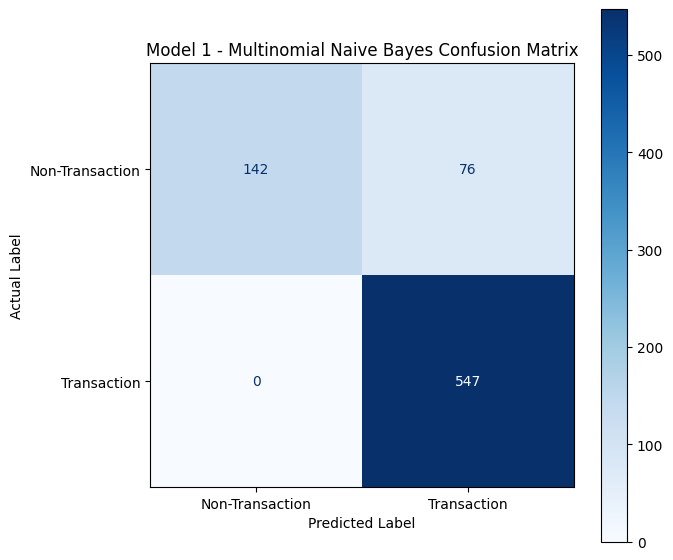

In [24]:
# ============================================================
# CELL — PLOT CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    values_format="d",
    cmap="Blues"
)

plt.title("Model 1 - Multinomial Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# CELL — INDIVIDUAL METRICS
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score

precision_transaction = precision_score(
    y_test,
    y_pred,
    pos_label="Transaction"
)

recall_transaction = recall_score(
    y_test,
    y_pred,
    pos_label="Transaction"
)

f1_transaction = f1_score(
    y_test,
    y_pred,
    pos_label="Transaction"
)

print(f"Transaction Precision : {precision_transaction * 100:.2f}%")
print(f"Transaction Recall    : {recall_transaction * 100:.2f}%")
print(f"Transaction F1-Score  : {f1_transaction * 100:.2f}%")

Transaction Precision : 87.80%
Transaction Recall    : 100.00%
Transaction F1-Score  : 93.50%


In [26]:
# ============================================================
# CELL — CORRECT / INCORRECT PREDICTIONS
# ============================================================

results_df = pd.DataFrame({
    "SMS": X_test.values,
    "Actual": y_test.values,
    "Predicted": y_pred
})

results_df["Correct"] = (
    results_df["Actual"] == results_df["Predicted"]
)

correct_count = results_df["Correct"].sum()
incorrect_count = (~results_df["Correct"]).sum()

print("Correct predictions  :", correct_count)
print("Incorrect predictions:", incorrect_count)
print("Total test samples   :", len(results_df))

Correct predictions  : 689
Incorrect predictions: 76
Total test samples   : 765


In [27]:
# ============================================================
# CELL — INCORRECT PREDICTIONS
# ============================================================

incorrect_predictions = results_df[
    results_df["Correct"] == False
].copy()

print("Number of incorrect predictions:", len(incorrect_predictions))

display(
    incorrect_predictions[
        ["SMS", "Actual", "Predicted"]
    ].head(30)
)

Number of incorrect predictions: 76


,SMS,Actual,Predicted
7,"Dear Sir/Madam, Your A/C 011-7788****02 has be...",Non-Transaction,Transaction
17,"LANKAPAY - ONLINE Transfer of LKR 9,026.42 to ...",Non-Transaction,Transaction
23,LANKAPAY - ONLINE Transfer of LKR 914.50 to A/...,Non-Transaction,Transaction
35,"Your payment/recharge of Rs.13,443.00 to 71128...",Non-Transaction,Transaction
58,Your payment/recharge of Rs.475.00 to 74077503...,Non-Transaction,Transaction
70,Billpay of LKR 748.00 to LECO on 2026-07-19 20...,Non-Transaction,Transaction
82,"Your payment/recharge of Rs.97,646.67 to 71848...",Non-Transaction,Transaction
98,Your Card Payment for Course Registration Fee ...,Non-Transaction,Transaction
99,"Your payment/recharge of Rs.11,013.00 to 75241...",Non-Transaction,Transaction
110,Billpay of LKR 711.42 to CEB on 2026-06-17 19:...,Non-Transaction,Transaction


In [28]:
# ============================================================
# CELL — FALSE POSITIVE / FALSE NEGATIVE ANALYSIS
# ============================================================

false_positives = results_df[
    (results_df["Actual"] == "Non-Transaction") &
    (results_df["Predicted"] == "Transaction")
]

false_negatives = results_df[
    (results_df["Actual"] == "Transaction") &
    (results_df["Predicted"] == "Non-Transaction")
]

print("False Positives :", len(false_positives))
print("False Negatives :", len(false_negatives))

False Positives : 76
False Negatives : 0


In [29]:
# ============================================================
# CELL — DISPLAY FALSE POSITIVES
# ============================================================

print("FALSE POSITIVES")
print("Non-Transaction messages predicted as Transaction")
print("=" * 70)

display(
    false_positives[
        ["SMS", "Actual", "Predicted"]
    ].reset_index(drop=True).head(50)
)

FALSE POSITIVES
Non-Transaction messages predicted as Transaction


,SMS,Actual,Predicted
0,"Dear Sir/Madam, Your A/C 011-7788****02 has be...",Non-Transaction,Transaction
1,"LANKAPAY - ONLINE Transfer of LKR 9,026.42 to ...",Non-Transaction,Transaction
2,LANKAPAY - ONLINE Transfer of LKR 914.50 to A/...,Non-Transaction,Transaction
3,"Your payment/recharge of Rs.13,443.00 to 71128...",Non-Transaction,Transaction
4,Your payment/recharge of Rs.475.00 to 74077503...,Non-Transaction,Transaction
5,Billpay of LKR 748.00 to LECO on 2026-07-19 20...,Non-Transaction,Transaction
6,"Your payment/recharge of Rs.97,646.67 to 71848...",Non-Transaction,Transaction
7,Your Card Payment for Course Registration Fee ...,Non-Transaction,Transaction
8,"Your payment/recharge of Rs.11,013.00 to 75241...",Non-Transaction,Transaction
9,Billpay of LKR 711.42 to CEB on 2026-06-17 19:...,Non-Transaction,Transaction


In [31]:
# ============================================================
# CELL — FINAL MODEL PERFORMANCE SUMMARY
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import pandas as pd

# ------------------------------------------------------------
# 1. Make sure predictions exist
# ------------------------------------------------------------

# If y_pred does not exist, generate predictions again
if "y_pred" not in globals():
    y_pred = mnb_model.predict(X_test_tfidf)

# ------------------------------------------------------------
# 2. Calculate all metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision_transaction = precision_score(
    y_test,
    y_pred,
    pos_label="Transaction",
    zero_division=0
)

recall_transaction = recall_score(
    y_test,
    y_pred,
    pos_label="Transaction",
    zero_division=0
)

f1_transaction = f1_score(
    y_test,
    y_pred,
    pos_label="Transaction",
    zero_division=0
)

# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

labels = ["Non-Transaction", "Transaction"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

# ------------------------------------------------------------
# 4. Correct / incorrect predictions
# ------------------------------------------------------------

correct_count = (y_test.values == y_pred).sum()
incorrect_count = len(y_test) - correct_count

# False positives:
# Actual Non-Transaction → Predicted Transaction
false_positives = cm[0, 1]

# False negatives:
# Actual Transaction → Predicted Non-Transaction
false_negatives = cm[1, 0]

# ------------------------------------------------------------
# 5. Create summary table
# ------------------------------------------------------------

model_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Transaction Precision",
        "Transaction Recall",
        "Transaction F1-Score",
        "Correct Predictions",
        "Incorrect Predictions",
        "False Positives",
        "False Negatives"
    ],
    "Value": [
        f"{accuracy * 100:.2f}%",
        f"{precision_transaction * 100:.2f}%",
        f"{recall_transaction * 100:.2f}%",
        f"{f1_transaction * 100:.2f}%",
        correct_count,
        incorrect_count,
        false_positives,
        false_negatives
    ]
})

display(model_summary)

# ------------------------------------------------------------
# 6. Print confusion matrix
# ------------------------------------------------------------

print("\nConfusion Matrix:")
print(cm)

print("\nModel 1 evaluation completed successfully.")

,Metric,Value
0,Accuracy,90.07%
1,Transaction Precision,87.80%
2,Transaction Recall,100.00%
3,Transaction F1-Score,93.50%
4,Correct Predictions,689
5,Incorrect Predictions,76
6,False Positives,76
7,False Negatives,0



Confusion Matrix:
[[142  76]
 [  0 547]]

Model 1 evaluation completed successfully.


In [32]:
# ============================================================
# CELL — CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print("=" * 70)
print("MODEL 1 — CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        labels=["Non-Transaction", "Transaction"],
        target_names=["Non-Transaction", "Transaction"],
        digits=4,
        zero_division=0
    )
)

MODEL 1 — CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Non-Transaction     1.0000    0.6514    0.7889       218
    Transaction     0.8780    1.0000    0.9350       547

       accuracy                         0.9007       765
      macro avg     0.9390    0.8257    0.8620       765
   weighted avg     0.9128    0.9007    0.8934       765



In [34]:
# ============================================================
# CELL — SAVE MODEL 1
# ============================================================

import joblib

# Save Multinomial Naive Bayes model
joblib.dump(
    mnb_model,
    "model1_multinomial_nb.joblib"
)

# Save TF-IDF vectorizer
joblib.dump(
    tfidf,
    "model1_tfidf_vectorizer.joblib"
)

print("Model 1 saved successfully.")
print("✓ model1_multinomial_nb.joblib")
print("✓ model1_tfidf_vectorizer.joblib")

Model 1 saved successfully.
✓ model1_multinomial_nb.joblib
✓ model1_tfidf_vectorizer.joblib


In [36]:
# ============================================================
# CELL — CREATE ANDROID-COMPATIBLE JSON
# ============================================================

import json

# ------------------------------------------------------------
# Convert NumPy values to normal Python types
# ------------------------------------------------------------

# TF-IDF vocabulary
vocabulary = {
    str(word): int(index)
    for word, index in tfidf.vocabulary_.items()
}

# IDF values
idf_values = [
    float(value)
    for value in tfidf.idf_
]

# Class log priors
class_log_prior = [
    float(value)
    for value in mnb_model.class_log_prior_
]

# Feature log probabilities
feature_log_prob = [
    [float(value) for value in row]
    for row in mnb_model.feature_log_prob_
]

# ------------------------------------------------------------
# Build Android model JSON
# ------------------------------------------------------------

android_model = {
    "model_name": "Financial SMS Model 1",
    "algorithm": "Multinomial Naive Bayes",
    "feature_extraction": "TF-IDF",

    "lowercase": True,
    "strip_accents": "unicode",

    "ngram_range": [
        int(tfidf.ngram_range[0]),
        int(tfidf.ngram_range[1])
    ],

    "min_df": int(tfidf.min_df),
    "sublinear_tf": bool(tfidf.sublinear_tf),
    "max_features": int(tfidf.max_features),

    "classes": [
        str(class_name)
        for class_name in mnb_model.classes_
    ],

    "vocabulary": vocabulary,

    "idf": idf_values,

    "class_log_prior": class_log_prior,

    "feature_log_prob": feature_log_prob
}

# ------------------------------------------------------------
# Save JSON
# ------------------------------------------------------------

json_filename = "model1_mnb_android.json"

with open(
    json_filename,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        android_model,
        f,
        ensure_ascii=False,
        indent=2
    )

print("Android JSON created successfully.")
print("File:", json_filename)
print("Vocabulary size:", len(vocabulary))
print("IDF values:", len(idf_values))
print("Classes:", android_model["classes"])

Android JSON created successfully.
File: model1_mnb_android.json
Vocabulary size: 17059
IDF values: 17059
Classes: ['Non-Transaction', 'Transaction']


In [37]:
# ============================================================
# CELL — DOWNLOAD ANDROID MODEL
# ============================================================

from google.colab import files

files.download("model1_mnb_android.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
# ============================================================
# CELL — SAVE PYTHON MODEL FILES
# ============================================================

import joblib

joblib.dump(
    mnb_model,
    "model1_multinomial_nb.joblib"
)

joblib.dump(
    tfidf,
    "model1_tfidf_vectorizer.joblib"
)

print("Python model files saved successfully.")

Python model files saved successfully.
